**Double Pendulum Simulation**

Simulate a double pendulum for some specific amount of time.

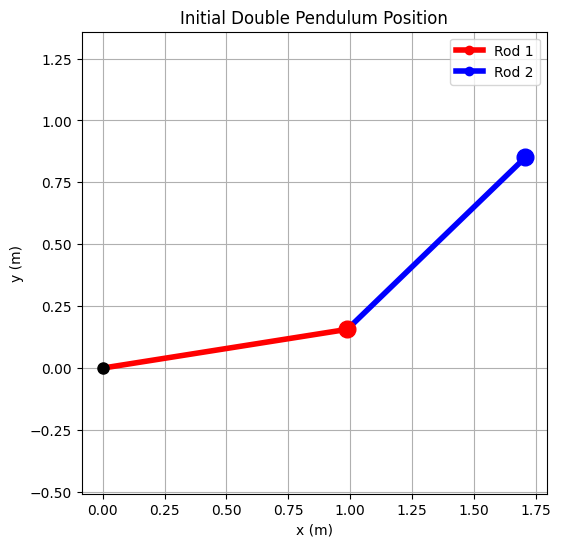

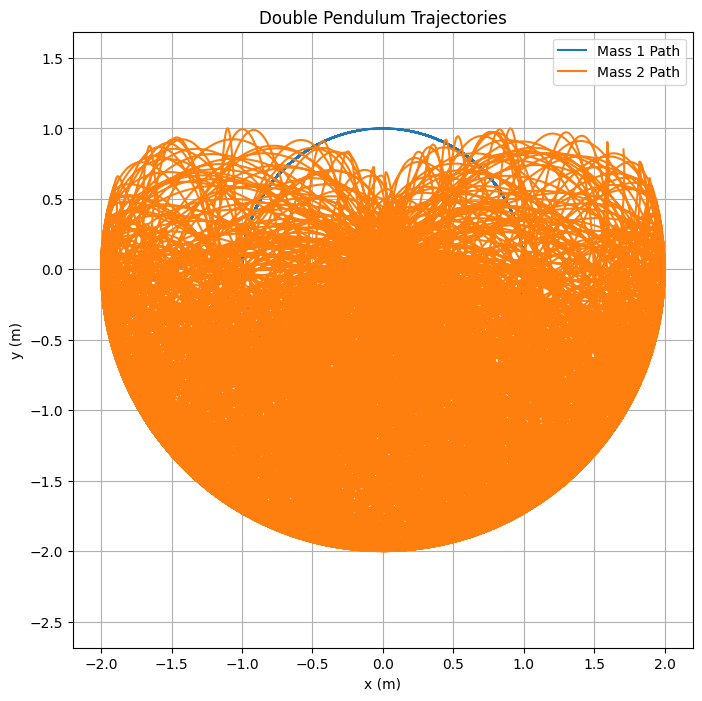

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def double_pendulum_derivs(t, y, m1, m2, L1, L2, g):
    theta1, omega1, theta2, omega2 = y
    
    delta = theta2 - theta1

    denom1 = (m1 + m2)*L1 - m2*L1*np.cos(delta)**2
    denom2 = (L2/L1)*denom1

    domega1 = (m2*L1*omega1**2*np.sin(delta)*np.cos(delta) +
               m2*g*np.sin(theta2)*np.cos(delta) +
               m2*L2*omega2**2*np.sin(delta) -
               (m1 + m2)*g*np.sin(theta1)) / denom1

    domega2 = (-m2*L2*omega2**2*np.sin(delta)*np.cos(delta) +
               (m1 + m2)*g*np.sin(theta1)*np.cos(delta) -
               (m1 + m2)*L1*omega1**2*np.sin(delta) -
               (m1 + m2)*g*np.sin(theta2)) / denom2

    return [omega1, domega1, omega2, domega2]

def simulate_double_pendulum(theta1_deg, theta2_deg, m1=1.0, m2=1.0, L1=1.0, L2=1.0, g=9.81, 
                             t_max=60, dt=0.01):
    # converts degrees to radians
    theta1 = np.radians(theta1_deg)
    theta2 = np.radians(theta2_deg)

    # initial state
    y0 = [theta1, 0.0, theta2, 0.0]

    t_span = (0, t_max)
    t_eval = np.arange(0, t_max, dt)

    sol = solve_ivp(double_pendulum_derivs, t_span, y0, t_eval=t_eval, method='DOP853',
                    args=(m1, m2, L1, L2, g),
                    rtol=1e-9, atol=1e-11)

    return sol

def get_positions(sol, L1, L2):
    theta1 = sol.y[0]
    theta2 = sol.y[2]

    x1 = L1 * np.sin(theta1)
    y1 = -L1 * np.cos(theta1)

    x2 = x1 + L2 * np.sin(theta2)
    y2 = y1 - L2 * np.cos(theta2)

    return x1, y1, x2, y2

def plot_pendulum(x1, y1, x2, y2):
    plt.figure(figsize=(8,8))
    plt.plot(x1, y1, label='Mass 1 Path')
    plt.plot(x2, y2, label='Mass 2 Path')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('Double Pendulum Trajectories')
    plt.legend()
    plt.axis('equal')
    plt.grid()
    plt.show()
    
def plot_initial_position(theta1_deg, theta2_deg, L1=1.0, L2=1.0):
    theta1 = np.radians(theta1_deg)
    theta2 = np.radians(theta2_deg)

    x1 = L1 * np.sin(theta1)
    y1 = -L1 * np.cos(theta1)

    x2 = x1 + L2 * np.sin(theta2)
    y2 = y1 - L2 * np.cos(theta2)

    plt.figure(figsize=(6,6))
    plt.plot([0, x1], [0, y1], 'ro-', lw=4, label='Rod 1')
    plt.plot([x1, x2], [y1, y2], 'bo-', lw=4, label='Rod 2')

    plt.plot(0, 0, 'ko', markersize=8)  # pivot
    plt.plot(x1, y1, 'ro', markersize=12)  # mass 1
    plt.plot(x2, y2, 'bo', markersize=12)  # mass 2

    plt.title('Initial Double Pendulum Position')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.axis('equal')
    plt.grid()
    plt.legend()
    plt.show()

# set your initial angles here
# lowkey likely a way better way than getting input tbh
# honestly just hard code it...
theta1_deg = float(input("Enter initial angle theta1 (degrees from vertical down): "))
theta2_deg = float(input("Enter initial angle theta2 (degrees from vertical down): "))

plot_initial_position(theta1_deg, theta2_deg)

# Starting Parameters
m1 = 1.0 # kg
m2 = 1.0
L1 = 1.0 # length of arms
L2 = 1.0
g = 9.81 # gravity
t_max = 3600 # Simulation Duration (seconds)
dt = 0.01

sol = simulate_double_pendulum(theta1_deg, theta2_deg, m1, m2, L1, L2, g, t_max, dt)
x1, y1, x2, y2 = get_positions(sol, L1, L2)
plot_pendulum(x1, y1, x2, y2)


**IGNORE ME**

This method incorrectly uses a pre-made wave form as a carrier wave which is not correct.


In [ ]:
from scipy.io import wavfile
from scipy.signal import square, sawtooth
import numpy as np

def generate_waveform(wave_type, freq, t):
    if wave_type == 'sine':
        return np.sin(2 * np.pi * freq * t)
    elif wave_type == 'square':
        return square(2 * np.pi * freq * t)
    elif wave_type == 'triangle':
        return sawtooth(2 * np.pi * freq * t, width=0.5)
    elif wave_type == 'sawtooth':
        return sawtooth(2 * np.pi * freq * t)
    else:
        raise ValueError(f"Unsupported wave type: {wave_type}")

def apply_echo(signal, fs, delay=0.3, decay=0.5):
    delay_samples = int(delay * fs)
    echoed = np.copy(signal)
    for i in range(delay_samples, len(signal)):
        echoed[i] += decay * signal[i - delay_samples]
    # Normalize to prevent clipping
    max_val = np.max(np.abs(echoed))
    if max_val > 1.0:
        echoed = echoed / max_val
    return echoed

def angles_to_sound(theta1, theta2, fs=44100, base_freq=440,
                    wave_type='sine', echo=False, echo_delay=0.3, echo_decay=0.5,
                    filename="pendulum_sound.wav"):
    """
    Convert theta angles to stereo audio file using amplitude modulation with optional echo.
    """
    duration = len(theta1) / fs
    t = np.linspace(0, duration, len(theta1))

    norm_theta1 = np.clip(theta1 / np.pi, -1, 1)
    norm_theta2 = np.clip(theta2 / np.pi, -1, 1)

    base_wave = generate_waveform(wave_type, base_freq, t)
    print(base_wave)
    
    left = base_wave * norm_theta1
    right = base_wave * norm_theta2

    if echo:
        left = apply_echo(left, fs, delay=echo_delay, decay=echo_decay)
        right = apply_echo(right, fs, delay=echo_delay, decay=echo_decay)

    stereo = np.vstack((left, right)).T
    stereo_int16 = np.int16(stereo * 32767)
    wavfile.write(filename, fs, stereo_int16)
    print(f"Saved: {filename}")


In [ ]:
from scipy.signal import resample

theta1 = sol.y[0]
theta2 = sol.y[2]

# Resample to audio rate
fs = 44100
samples = int(fs * sol.t[-1])
theta1_resampled = resample(theta1, samples)
theta2_resampled = resample(theta2, samples)

# Sonify with triangle wave and echo
angles_to_sound(theta1_resampled, theta2_resampled,
                fs=fs,
                base_freq=220,
                wave_type='triangle',
                echo=False,
                echo_delay=0,
                echo_decay=0,
                filename='pendulum.wav')


**Debug Functions**

Plots the normalized amplitudes for a given double pendulum simulation (Takes a While)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_normalized_amplitudes(theta1, theta2, fs=44100, duration_limit_sec=None, title="Pendulum Amplitude Envelopes"):
    """
    Plot the normalized amplitude (|theta| / max(|theta|)) of theta1 and theta2.
    Optionally limit duration in seconds.
    """
    # Normalize
    norm_theta1 = theta1 / np.max(np.abs(theta1))
    norm_theta2 = theta2 / np.max(np.abs(theta2))

    # Get amplitude envelope (abs value)
    amp1 = np.abs(norm_theta1)
    amp2 = np.abs(norm_theta2)

    # Optional duration limit
    if duration_limit_sec is not None:
        limit_samples = int(fs * duration_limit_sec)
        amp1 = amp1[:limit_samples]
        amp2 = amp2[:limit_samples]
        time = np.linspace(0, duration_limit_sec, limit_samples)
    else:
        time = np.linspace(0, len(theta1) / fs, len(theta1))

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(time, amp1, label='|Theta1|', alpha=0.8)
    plt.plot(time, amp2, label='|Theta2|', alpha=0.8)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_normalized_amplitudes(theta1_resampled, theta2_resampled, fs=44100, duration_limit_sec=3400)

**Double Pendulum Angles as Raw Data**

This saves the angles of theta 1 and theta 2 as two seperate raw PCM files. 

Audacity can be used to recombine them. (Click Import, then Select 'Raw Data')

In [3]:
from scipy.signal import resample

def save_angle_as_raw_pcm(theta, filename, normalize=True, speed_factor=600.0):
    """
    Save pendulum angle array as raw PCM 16-bit signed integer data with optional speed adjustment.

    Parameters:
    - theta: np.array of angles (e.g., radians over time)
    - filename: str, path to save .raw file
    - normalize: bool, whether to normalize to [-1, 1]
    - speed_factor: float, >1 = faster, <1 = slower
    """
    if speed_factor != 1.0:
        new_length = int(len(theta) / speed_factor)
        theta = resample(theta, new_length)

    if normalize:
        max_val = np.max(np.abs(theta))
        if max_val > 0:
            theta_norm = theta / max_val
        else:
            theta_norm = theta
    else:
        theta_norm = theta

    theta_pcm = np.int16(theta_norm * 32767)

    with open(filename, 'wb') as f:
        f.write(theta_pcm.tobytes())

    print(f"Saved raw PCM to: {filename} (speed_factor={speed_factor})")

In [4]:
from scipy.signal import resample

fs = 44100
samples = int(fs * sol.t[-1])

theta1_resampled = resample(sol.y[0], samples)
theta2_resampled = resample(sol.y[2], samples)

save_angle_as_raw_pcm(theta1_resampled, "theta1_left.raw")
save_angle_as_raw_pcm(theta2_resampled, "theta2_right.raw")

Saved raw PCM to: theta1_left.raw (speed_factor=600.0)
Saved raw PCM to: theta2_right.raw (speed_factor=600.0)


Function here (See Below) is just to combine the Raw Data without needing Audacity

In [5]:
import numpy as np
from scipy.io.wavfile import write as wav_write

def combine_raw_pcm_to_wav(left_filename, right_filename, wav_filename, fs=44100):
    """
    Combine two mono raw PCM files into a stereo WAV file.

    Parameters:
    - left_filename: str, path to .raw PCM file for the left channel
    - right_filename: str, path to .raw PCM file for the right channel
    - wav_filename: str, output .wav file path
    - fs: int, sample rate (default 44100)
    """
    # Read raw 16-bit PCM data
    left = np.fromfile(left_filename, dtype=np.int16)
    right = np.fromfile(right_filename, dtype=np.int16)

    # Ensure they are the same length
    min_len = min(len(left), len(right))
    left = left[:min_len]
    right = right[:min_len]

    # Stack into stereo: shape = (samples, 2)
    stereo = np.stack([left, right], axis=-1)

    # Write to WAV
    wav_write(wav_filename, fs, stereo)
    print(f"Stereo WAV written to: {wav_filename}")

In [6]:
combine_raw_pcm_to_wav("theta1_left.raw", "theta2_right.raw", "pendulum.wav")

Stereo WAV written to: pendulum.wav


Below are the functions that will create and combine the raw files all at once without the need for Audacity.

You can also specify the degree to which each sounds plays in either ear.

In [ ]:
import numpy as np
from scipy.signal import resample
from scipy.io.wavfile import write as wav_write

def pan_value_to_gain(pan):
    """
    Convert a pan value (-1.0 full left, 1.0 full right) to stereo gains.
    Uses constant power panning law.
    """
    angle = (pan + 1) * 0.25 * np.pi  # maps [-1,1] to [0, π/2]
    left_gain = np.cos(angle)
    right_gain = np.sin(angle)
    return left_gain, right_gain

def save_angles_as_stereo_wav(theta_left, theta_right, wav_filename, 
                               normalize=True, speed_factor=600.0, fs=44100,
                               left_pan=-1.0, right_pan=1.0):
    """
    Convert two angle arrays to a stereo WAV file with optional speed and pan.

    Parameters:
    - theta_left, theta_right: np.arrays of angles
    - wav_filename: str, path to save .wav file
    - normalize: bool, whether to normalize to [-1, 1]
    - speed_factor: float, >1 = faster
    - fs: int, sample rate
    - left_pan, right_pan: floats in [-1.0, 1.0], stereo panning
    """
    def preprocess(theta):
        if speed_factor != 1.0:
            new_length = int(len(theta) / speed_factor)
            theta = resample(theta, new_length)
        if normalize:
            max_val = np.max(np.abs(theta))
            if max_val > 0:
                theta = theta / max_val
        return theta.astype(np.float32)

    # Preprocess both
    left_data = preprocess(theta_left)
    right_data = preprocess(theta_right)

    # Truncate to shortest length
    min_len = min(len(left_data), len(right_data))
    print(min_len)
    left_data = left_data[:min_len]
    right_data = right_data[:min_len]

    # Pan gains
    ll, lr = pan_value_to_gain(left_pan)
    rl, rr = pan_value_to_gain(right_pan)

    # Apply stereo mix
    left_channel = (left_data * ll) + (right_data * rl)
    right_channel = (left_data * lr) + (right_data * rr)

    # Clip and convert to int16 PCM
    left_channel = np.clip(left_channel * 32767, -32768, 32767).astype(np.int16)
    right_channel = np.clip(right_channel * 32767, -32768, 32767).astype(np.int16)

    stereo = np.stack([left_channel, right_channel], axis=-1)

    # Save
    wav_write(wav_filename, fs, stereo)
    print(f"Stereo WAV written to: {wav_filename} with pans L={left_pan}, R={right_pan}, speed_factor={speed_factor}")


In [ ]:
from scipy.signal import resample

theta1 = sol.y[0]
theta2 = sol.y[2]

# Resample to audio rate
fs = 44100
samples = int(fs * sol.t[-1])
theta1_resampled = resample(theta1, samples)
theta2_resampled = resample(theta2, samples)

save_angles_as_stereo_wav(theta1, theta2, "output.wav", normalize=True, speed_factor=600.0)